# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习 
- 设计题目：基于卷积神经网络的静态手语字母识别系统 
- 姓    名：郭许栩  
- 学    号：20234080310  
- 班    级：本23数据03班  
- 指导教师：丁平尖 
- 提交日期：2026年6月20日  

## 二、摘要

手语识别是计算机视觉与人工智能领域的重要研究方向，在听障人士辅助交流、人机交互等场景中具有广阔的应用前景。针对静态手语字母识别问题，本文设计并实现了一种基于卷积神经网络（CNN）的静态手语字母识别系统，并通过多模型对比验证了卷积神经网络在图像分类任务中的优势。

实验采用ASL Alphabet公开数据集，原始数据集包含26个英文字母类别，共206137张手语图像。考虑到计算资源限制，实验随机抽取50000张图像作为研究对象，并完成图像尺寸统一、Tensor转换以及数据归一化等预处理操作。实验分别构建了多层感知机（MLP）和卷积神经网络（CNN）两种模型进行对比，并通过调整Epoch、Batch Size等超参数以及引入学习率调度策略，对模型训练过程进行了优化。

实验结果表明，CNN模型在验证集上取得了97.21%的分类准确率，明显优于MLP模型的91.92%。同时，通过训练准确率曲线、模型对比、混淆矩阵以及错误样本分析等实验结果可以看出，卷积神经网络能够有效提取手语图像的空间特征，对大多数手语字母实现准确分类，仅在少量姿态相近的字母之间存在误分类现象，验证了CNN在静态手语字母识别任务中的有效性和优越性。

**关键词：** 手语识别；卷积神经网络；深度学习；图像分类；PyTorch


## 三、问题定义与需求分析

### 3.1 项目背景与意义

手语是听障人士进行日常交流的重要方式，但传统交流依赖双方掌握手语知识，限制了沟通效率。随着人工智能和计算机视觉技术的发展，利用深度学习实现手语自动识别成为可能。

本选题来源于听障人士辅助交流的实际需求，旨在利用深度学习技术实现静态手语字母识别，将手势信息自动转换为对应字母，从而提高人机交互和辅助沟通的便利性。

从科研角度来看，手语识别是计算机视觉与模式识别领域的重要研究方向。通过构建和训练图像分类模型，可以验证深度学习方法在手势识别任务中的应用效果，并为后续实时手语识别系统和连续手语翻译系统的研究提供基础。


### 3.2 问题描述

本项目研究目标为静态手语字母识别任务。系统输入为单张RGB彩色手语图像，输出为对应的英文字母类别（A-Z）。

从机器学习任务角度来看，该问题属于监督学习中的多分类图像分类任务。训练过程中，模型通过学习大量已标注的手语图像样本，建立图像特征与字母类别之间的映射关系，从而实现对未知手语图像的自动识别。

本项目采用分类准确率（Accuracy）作为主要评价指标，准确率表示模型预测正确的样本数量占总样本数量的比例，其计算公式如下：

Accuracy = 正确预测样本数 / 总样本数 × 100%

除准确率指标外，实验还结合混淆矩阵、错误样本分析以及不同模型间的性能对比，对模型分类效果进行综合评估。

## 四、数据集说明与预处理

### 4.1 数据来源与规模

实验采用公开数据集 ASL Alphabet Dataset 作为实验数据，该数据集来源于 Kaggle 平台，包含美国手语（American Sign Language，ASL）26个英文字母对应的静态手势图像。原始数据集共包含206137张图像，涵盖A至Z共26个类别。


### 4.2 数据可视化与分析

In [17]:
import import_ipynb
from torchvision import transforms
import ASL_Alphabet_Recognition as asl

import importlib
# 重新加载模块
importlib.reload(asl)

ModuleSpec(name='ASL_Alphabet_Recognition', loader=<import_ipynb.NotebookLoader object at 0x00000237DF834790>, origin='ASL_Alphabet_Recognition.ipynb')

> 数据集基本信息统计

In [2]:
asl.dataset_info()

完整数据集: 206137
类别数: 26
类别名称:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


> 类别分布统计 

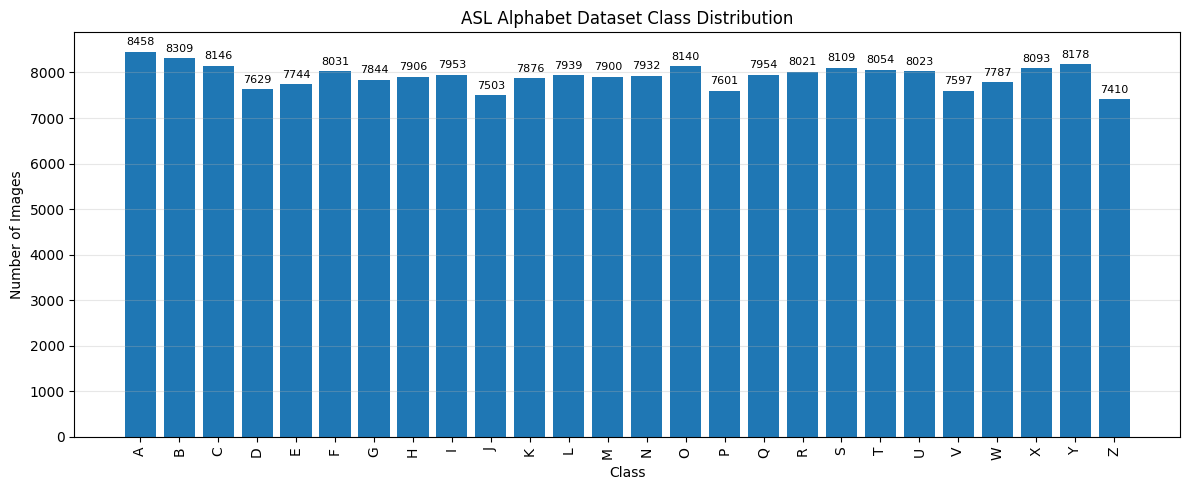

In [3]:
asl.plot_class_distribution()

从类别分布图可知，数据集共26个字母类别，各类别样本数在7,400至8,500之间波动，整体较为均衡，其中Z类最少（7,410张），A类最多（8,458张）。轻微不均衡对模型影响有限，训练时无需特殊处理。

> 样本示例  

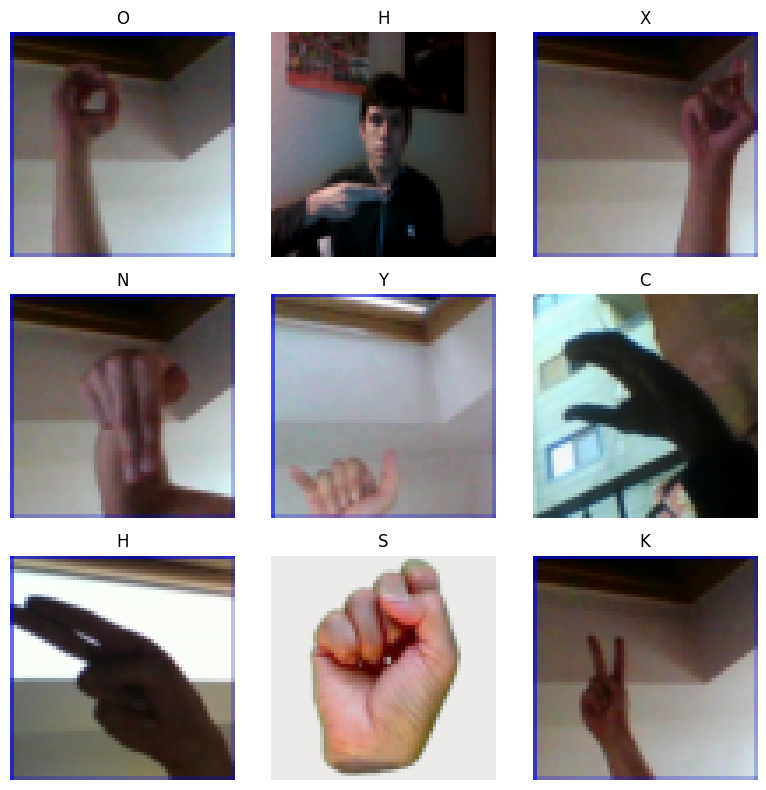

In [20]:
asl.show_samples()

随机抽取数据集中的部分图像样本进行可视化，如上图所示。可以观察到，不同类别的手语字母具有明显不同的手部姿态特征，例如手指数量、伸展方向以及手掌形状等，这些特征构成了后续分类任务的重要判别依据。

此外，样本图像在拍摄角度、背景环境、光照条件以及肤色方面存在一定差异，使得数据具有较好的多样性。虽然这些因素会增加分类难度，但能够有效提升模型的鲁棒性和泛化能力。整体来看，数据集样本质量较高，类别特征较为清晰，具有较好的类别区分度，能够为后续图像分类模型的训练与性能评估提供可靠的数据基础。

### 4.3 预处理流程
为了提高模型训练效率并保证输入数据格式统一，本项目对原始图像数据进行了预处理。
> （1）数据清洗

ASL Alphabet 数据集已完成规范化整理，图像均按照类别存放于对应文件夹中。实验前对数据集进行完整性检查，确保了不存在缺失样本、损坏图像及无法读取的文件，为后续训练提供可靠的数据基础。
> （2）数据标注

ASL Alphabet 数据集已完成类别标注，每张图像均对应一个手语字母类别。项目采用 PyTorch 的 ImageFolder 自动读取数据集，并根据文件夹名称生成对应标签，实现图像与类别信息的自动关联。

> （3）数据归一化

为了保证模型输入数据格式统一，首先将所有图像调整为64×64像素大小。随后利用 ToTensor() 将图像转换为 Tensor 格式，并将像素值由0～255缩放至0～1区间。最后采用 Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]) 对图像进行标准化处理，使数据分布映射至约−1～1范围，从而提高模型训练过程的稳定性和收敛速度。

In [5]:
print(asl.get_transform()) 

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


> (4) 数据集划分

考虑到完整数据集规模较大，实验随机抽取50000张样本参与训练。

随后按照8:2比例随机划分训练集和验证集，其中训练集用于模型参数学习，验证集用于评估模型的分类性能和泛化能力。

In [6]:
train_loader, val_loader, _ = asl.get_dataloaders()

print("训练集样本数：", len(train_loader.dataset))
print("验证集样本数：", len(val_loader.dataset))

训练集样本数： 40000
验证集样本数： 10000


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

本项目针对静态手语字母识别任务，首先构建基准模型用于对比分析。

基准模型采用多层感知机（Multi-Layer Perceptron，MLP），作为传统全连接神经网络结构，在图像分类任务中具有结构简单、计算效率高等特点。

MLP模型的核心思想是将二维图像数据展开为一维向量，然后通过全连接层进行特征学习与分类预测。然而，由于其无法有效利用图像的空间结构信息，因此在复杂图像任务中通常作为性能较弱的基准模型。

> （1）模型结构设计

本项目MLP模型结构如下：

输入图像（64×64×3）
     
        ↓
Flatten（展平）
      
        ↓
全连接层 Linear（12288 → 512）
      
        ↓
ReLU激活函数
       
        ↓
全连接层 Linear（512 → 26）
       
        ↓
输出层（26类手语字母分类）

> （2）模型代码调用

在代码实现中，通过如下方式构建MLP模型：

In [7]:
mlp_model = asl.create_mlp()
print(mlp_model)

MLP(
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=26, bias=True)
  )
)


> （3）设计特点
MLP模型具有以下特点：
- 结构简单，实现方便
- 参数全部来自全连接层
- 不具备卷积结构，无法提取局部特征
- 适合作为图像分类任务的基准模型

 ### 5.2 最终模型架构

本项目最终采用卷积神经网络（CNN）作为手语字母识别模型。模型主要由卷积特征提取模块和全连接分类模块两部分组成。

卷积部分包含两层卷积层（Conv2d）和两层最大池化层（MaxPool2d）。第一层卷积将输入图像通道数由3扩展至32，第二层卷积进一步扩展至64个特征图。卷积层均采用3×3卷积核，并使用ReLU激活函数引入非线性特征表达能力。每个卷积层后均接入最大池化层，用于降低特征图尺寸、减少参数数量并保留主要特征信息。

经过两次卷积与池化操作后，特征图尺寸由64×64逐步缩减为16×16，并形成64个特征通道。随后通过Flatten层将二维特征图展开为一维特征向量，共16384个特征。

分类部分采用两层全连接层。其中第一层全连接层将16384维特征映射至512维隐藏层，并使用ReLU激活函数进行非线性变换；第二层全连接层输出26个神经元，对应26个英文字母类别，实现最终分类预测。


> （1）模型结构

CNN模型结构代码调用

In [8]:
model = asl.create_model()
print(model)

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=26, bias=True)
  )
)


> （2）激活函数设计

本项目在CNN与MLP中均采用ReLU作为激活函数，其表达形式如下：

    f(x) = max(0, x)

ReLU具有以下优点：

    计算简单
    收敛速度快
    能有效缓解梯度消失问题

因此，本项目CNN与MLP均采用ReLU作为隐藏层激活函数。

> （3）模型选择依据

选择CNN作为最终模型的原因如下：

- 图像结构适配性更强

CNN能够保留图像的空间结构信息，而MLP会破坏像素之间的空间关系。

- 局部特征提取能力

卷积操作能够自动学习局部特征，如边缘、手型轮廓等。

- 参数共享机制

相比全连接网络，CNN参数量更少，泛化能力更强。

- 实验对比需求

本项目通过MLP与CNN进行对比实验，用以验证CNN在图像分类任务中的优势。

综合考虑CNN在图像分类任务中的优势以及本项目特点，最终选择CNN作为静态手语字母识别模型，并在后续实验中验证其性能。

## 六、实验与结果分析

### 6.1 实验环境
> （1）硬件环境

In [9]:
import platform
import torch
import psutil

# CPU
print("CPU:", platform.processor())

# 内存
mem = psutil.virtual_memory()
print("内存: {:.2f} GB".format(mem.total / 1024**3))


CPU: AMD64 Family 25 Model 116 Stepping 1, AuthenticAMD
内存: 27.69 GB


> （2）软件环境

In [10]:
import pkg_resources

# Python版本
print("Python版本:", platform.python_version())

# PyTorch版本
print("PyTorch版本:", torch.__version__)

libs = ["torch", "torchvision", "numpy", "matplotlib"]
print("===== 主要依赖库 =====")
for lib in libs:
    try:
        version = pkg_resources.get_distribution(lib).version
        print(f"{lib}: {version}")
    except:
        print(f"{lib}: 未安装")

C:\Users\14778\AppData\Local\Temp\ipykernel_16612\2588734693.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Python版本: 3.10.20
PyTorch版本: 2.12.0+cpu
===== 主要依赖库 =====
torch: 2.12.0
torchvision: 0.27.0
numpy: 2.2.6
matplotlib: 3.10.9


### 6.2 评价指标

> （1）分类准确率（Accuracy）

分类准确率用于衡量模型预测正确的比例，计算公式如下：

Accuracy = 正确预测样本数 / 总样本数

在训练过程中分别记录：
- 训练集准确率（Train Accuracy）
- 验证集准确率（Validation Accuracy）
用于判断模型的学习能力与泛化能力。

> （2）混淆矩阵（Confusion Matrix）

混淆矩阵用于分析模型在各类别上的分类情况，能够直观展示：

- 正确分类情况（对角线）
- 错误分类分布（非对角线）

> （3）错误样本分析

通过可视化错误分类样本，分析模型容易混淆的手语类别，从而进一步优化模型结构或数据集质量。

6.3 超参数设置与调优

> （1）调参方法

本项目采用经验初始化与逐步调参相结合的方法对模型超参数进行优化。首先参考经典图像分类任务的常用参数配置完成模型的初始训练，再结合训练集和验证集准确率变化情况，对关键超参数进行逐步调整，以获得较好的分类性能。

初始实验采用 Epoch=5、Batch Size=64、Learning Rate=0.001 的参数配置进行训练，主要用于验证模型结构的可行性。实验结果表明，在第5轮训练结束时，训练准确率和验证准确率仍保持上升趋势，模型尚未充分收敛，因此决定适当增加训练轮数，使模型能够进一步学习图像特征。

随后，将训练轮数（Epoch）由5增加至10。重新训练后，模型在后续Epoch中的验证准确率继续提升，说明增加训练轮数能够有效提高模型的学习效果。

在批量大小方面，将 Batch Size 由64调整为128。调整后，每次参数更新能够利用更多样本计算梯度，在保证模型收敛效果的同时，提高了训练效率，并使训练过程更加稳定。

优化器仍采用 Adam，初始学习率保持为0.001。实验过程中发现，随着训练进行，模型后期准确率提升速度逐渐减缓，因此进一步引入 StepLR 学习率调度器，设置 step_size=5、gamma=0.1。当训练进行到第5轮后，学习率自动降低为原来的0.1倍，使模型能够以更小的步长继续优化参数，从而提高训练后期的收敛能力，并减少因学习率过大导致的参数震荡。

> （2）调参策略总结

本项目采用的超参数调优策略主要包括：

- 经验初始化法：参考经典CNN图像分类模型的常用参数作为初始配置；

- 逐步调整法：每次仅调整一个关键参数，并观察模型训练曲线及验证集准确率变化情况；

- 对比验证法：分别训练CNN与MLP模型，对比两种模型的分类性能；

- 学习率衰减策略：采用StepLR学习率调度器，在训练后期自动降低学习率，提高模型收敛能力。

综合多轮实验结果可以发现，增加训练轮数、适当增大Batch Size以及引入学习率调度策略后，两种模型的分类性能均有所提升。其中，CNN模型最终在验证集上取得了97.21%的分类准确率，明显优于MLP模型的91.92%，验证了所采用调参策略的有效性。

> （3）最终参数设置

本项目最终采用如下训练参数：
| 参数（Parameter） | 最终设置（Value） |
| :---------------- | :---------------- |
| Epoch | 10 |
| Batch Size | 128 |
| Learning Rate | 0.001 |
| Learning Rate Scheduler | StepLR（step_size=5，gamma=0.1） |
| Optimizer | Adam |
| Loss Function | CrossEntropyLoss |
| Input Size | 64 × 64 × 3 |
| Image Normalization | mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5] |
| Number of Classes | 26 |

### 6.4 主要实验结果

> （1）MLP与CNN训练过程

训练过程中分别记录：

- 每个epoch的训练准确率
- 每个epoch的验证准确率

MLP训练：

In [11]:
mlp_model, mlp_train_acc, mlp_val_acc = asl.train_model(
    asl.create_mlp(),
    "mlp_model.pth"
)


========== Epoch 1/10 ==========
Epoch [1/10] LR:0.001000 Train Acc:41.11% Val Acc:59.12%

========== Epoch 2/10 ==========
Epoch [2/10] LR:0.001000 Train Acc:67.38% Val Acc:70.11%

========== Epoch 3/10 ==========
Epoch [3/10] LR:0.001000 Train Acc:75.64% Val Acc:75.13%

========== Epoch 4/10 ==========
Epoch [4/10] LR:0.001000 Train Acc:80.56% Val Acc:79.41%

========== Epoch 5/10 ==========
Epoch [5/10] LR:0.000100 Train Acc:84.08% Val Acc:81.17%

========== Epoch 6/10 ==========
Epoch [6/10] LR:0.000100 Train Acc:93.76% Val Acc:90.04%

========== Epoch 7/10 ==========
Epoch [7/10] LR:0.000100 Train Acc:95.83% Val Acc:90.57%

========== Epoch 8/10 ==========
Epoch [8/10] LR:0.000100 Train Acc:96.37% Val Acc:91.23%

========== Epoch 9/10 ==========
Epoch [9/10] LR:0.000100 Train Acc:96.79% Val Acc:91.56%

========== Epoch 10/10 ==========
Epoch [10/10] LR:0.000010 Train Acc:97.20% Val Acc:91.92%

模型保存成功


**MLP训练结果分析：**

从训练结果可以看出，随着训练轮数的增加，MLP模型的训练准确率和验证准确率均呈现逐步上升趋势，说明模型能够有效学习静态手语图像的特征。在第5轮训练后，学习率调度器开始降低学习率，模型仍保持稳定收敛，验证准确率继续提升。最终，MLP模型训练准确率达到97.20%，验证准确率达到91.92%，说明模型具有较好的分类能力，但训练准确率略高于验证准确率，表明模型存在一定程度的过拟合现象。


CNN训练：

In [12]:
cnn_model, cnn_train_acc, cnn_val_acc = asl.train_model(
    asl.create_model(),
    "cnn_model.pth"
)


========== Epoch 1/10 ==========
Epoch [1/10] LR:0.001000 Train Acc:55.88% Val Acc:82.18%

========== Epoch 2/10 ==========
Epoch [2/10] LR:0.001000 Train Acc:89.51% Val Acc:91.35%

========== Epoch 3/10 ==========
Epoch [3/10] LR:0.001000 Train Acc:95.48% Val Acc:92.91%

========== Epoch 4/10 ==========
Epoch [4/10] LR:0.001000 Train Acc:97.46% Val Acc:94.71%

========== Epoch 5/10 ==========
Epoch [5/10] LR:0.000100 Train Acc:98.57% Val Acc:94.62%

========== Epoch 6/10 ==========
Epoch [6/10] LR:0.000100 Train Acc:99.70% Val Acc:96.92%

========== Epoch 7/10 ==========
Epoch [7/10] LR:0.000100 Train Acc:99.95% Val Acc:97.00%

========== Epoch 8/10 ==========
Epoch [8/10] LR:0.000100 Train Acc:99.97% Val Acc:97.08%

========== Epoch 9/10 ==========
Epoch [9/10] LR:0.000100 Train Acc:99.98% Val Acc:97.10%

========== Epoch 10/10 ==========
Epoch [10/10] LR:0.000010 Train Acc:99.97% Val Acc:97.21%

模型保存成功


**CNN训练结果分析：**

从训练结果可以看出，CNN模型在训练初期准确率提升较快，第1轮验证准确率已达到82.18%，说明卷积神经网络能够快速提取手语图像的特征信息。随着训练轮数增加，训练准确率和验证准确率均持续提高。在第5轮训练后，学习率调度器开始降低学习率，模型仍保持稳定收敛，验证准确率进一步提升。经过10轮训练，CNN模型最终训练准确率达到99.97%，验证准确率达到97.21%，模型具有较高的分类准确率和较好的泛化能力，说明其能够较好地完成静态手语字母识别任务。


综合MLP和CNN模型的训练结果，下面将从训练曲线和最终分类准确率等方面对两种模型进行对比分析，以进一步验证CNN模型在静态手语字母识别任务中的优势。

> （2）准确率变化曲线

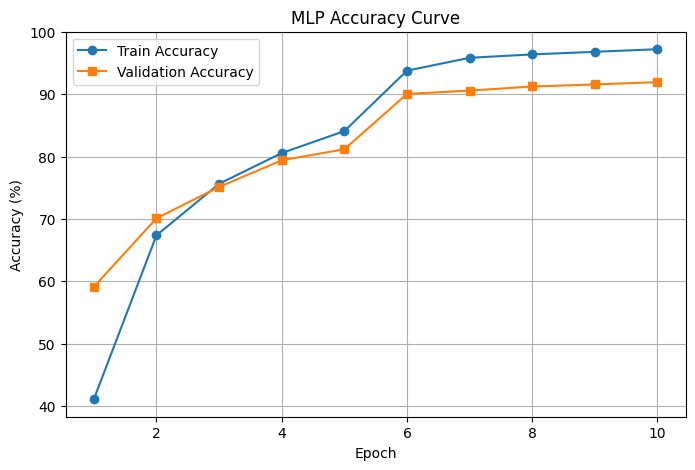

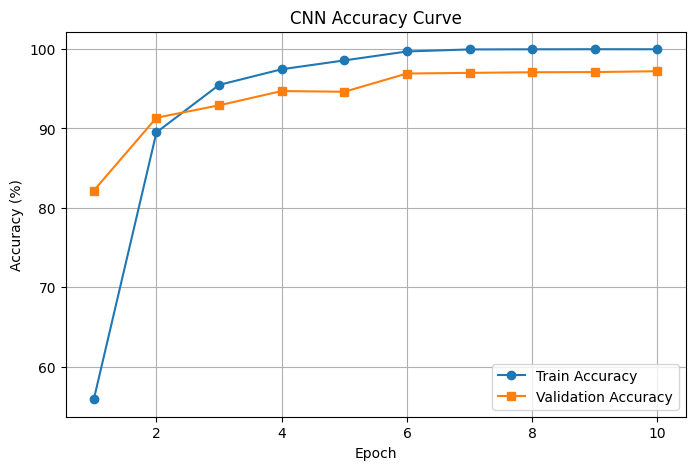

In [13]:
asl.plot_accuracy_curve(
    mlp_train_acc,
    mlp_val_acc,
    "MLP"
)
asl.plot_accuracy_curve(
    cnn_train_acc,
    cnn_val_acc,
    "CNN"
)

准确率曲线分析：

从MLP模型的准确率变化曲线可以看出，训练准确率和验证准确率均随着训练轮数增加而持续上升，整体变化趋势较为平稳。训练前期模型学习速度较快，在第6轮后准确率提升幅度逐渐减小，说明模型已逐步收敛。训练准确率始终略高于验证准确率，两条曲线之间存在一定间距，但未出现明显发散，表明模型具有一定的泛化能力，仅存在轻微过拟合现象。

从CNN模型的准确率变化曲线可以看出，模型在训练初期准确率提升速度明显快于MLP，第2轮验证准确率已超过90%，说明卷积神经网络能够快速学习图像特征。随着训练继续进行，两条曲线逐渐趋于平稳，并在第6轮后基本收敛。训练准确率与验证准确率始终保持较小差距，说明模型具有较好的泛化能力，训练过程稳定，没有出现明显的过拟合现象。

> （3）模型对比分析

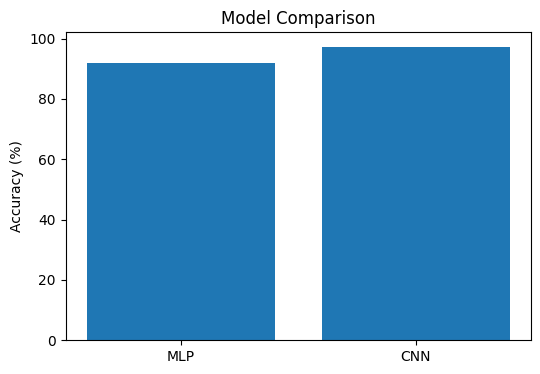

,Epoch,CNN Val Acc,MLP Val Acc
0,1,82.18,59.12
1,2,91.35,70.11
2,3,92.91,75.13
3,4,94.71,79.41
4,5,94.62,81.17
5,6,96.92,90.04
6,7,97.00,90.57
7,8,97.08,91.23
8,9,97.10,91.56
9,10,97.21,91.92


In [14]:
asl.compare_models(
    max(cnn_val_acc),
    max(mlp_val_acc)
)

asl.get_compare_table(cnn_val_acc, mlp_val_acc)

由模型对比图和验证集准确率对比表可以看出，CNN模型在各训练轮次中的验证准确率均高于MLP模型，且整体提升趋势更加稳定。经过10轮训练，CNN模型最终验证准确率达到97.21%，相比MLP模型的91.92%提高了5.29个百分点。这表明CNN能够更有效地提取图像的局部空间特征，在静态手语字母识别任务中具有更强的特征表达能力和分类性能，因此最终选择CNN作为本项目的识别模型。

### 6.5 可视化分析

> （1）混淆矩阵分析

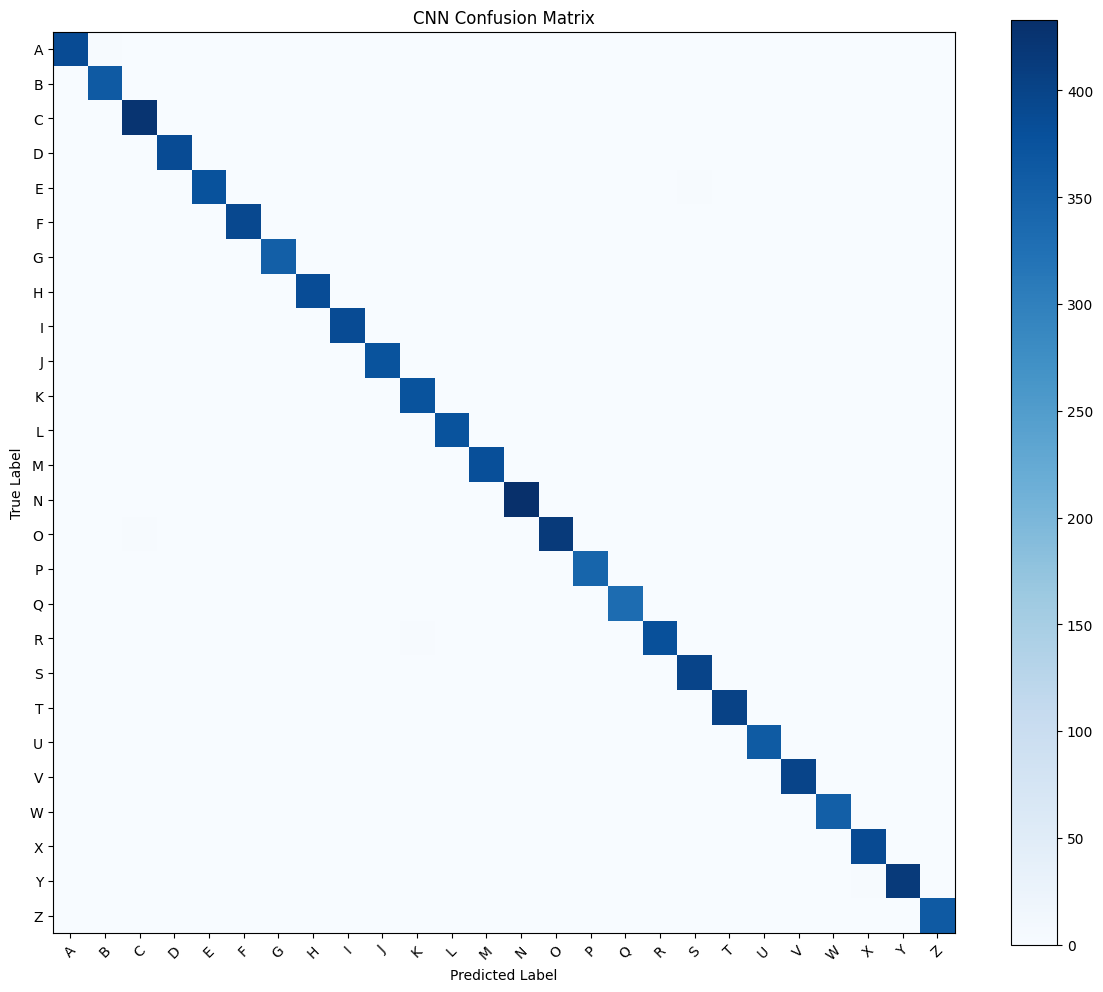

In [18]:
asl.plot_confusion_matrix()

混淆矩阵分析：

上图展示了CNN模型在验证集上的混淆矩阵。从图中可以看出，预测结果主要集中在主对角线上，说明模型预测类别与真实类别具有较高的一致性，大部分手语字母均能够被正确识别。与此同时，非对角线区域仅存在少量颜色分布，表明模型整体误分类数量较少，具有较好的分类性能。

结合实验结果可知，CNN模型在验证集上的最高准确率达到97.21%。混淆矩阵进一步验证了模型具有良好的特征提取能力和类别判别能力，能够较准确地完成26类静态手语字母的分类任务，达到了本项目的预期目标。

> （2）错误样本分析

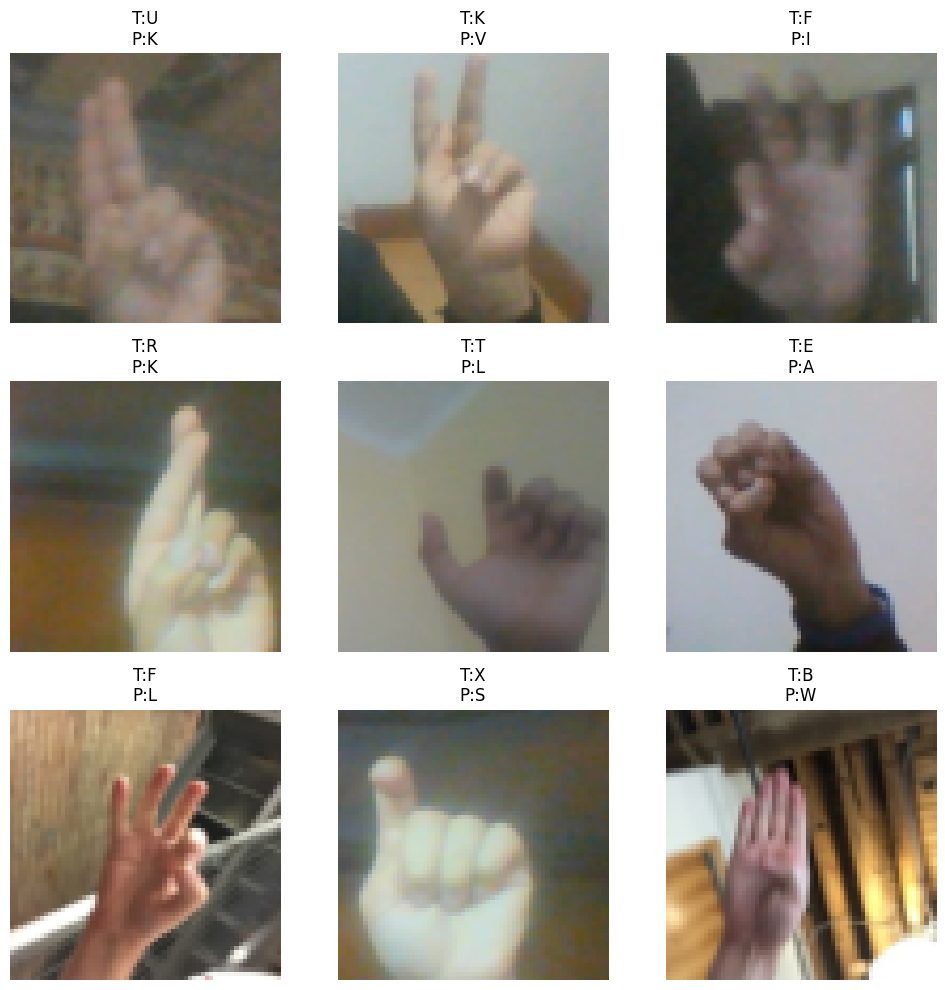

In [16]:
asl.show_error_samples()

错误样本分析

从图中的错误样本可以看出，虽然CNN模型整体识别准确率较高，但仍存在少量误分类情况。通过观察这些错误样本，可以发现模型产生错误主要有以下几个原因：

（1）部分手语字母手势形态十分相似
例如图中 U 被识别为 K、K 被识别为 V、R 被识别为 K 等情况，这些字母均以伸出两根手指为主要特征，仅在手指交叉方式、张开角度或拇指位置上存在细微差异，因此模型容易发生混淆。

（2）图像存在一定程度的模糊、光照变化或姿态变化影响了特征提取
部分错误样本存在明显的模糊、噪声或光照不足现象，如图中的 F、T、X 等样本，导致手指边缘和关节轮廓不够清晰，使卷积神经网络难以准确提取关键特征，从而影响分类结果。

（3）拍摄角度和手势姿态存在差异
部分样本由于拍摄角度、手掌旋转方向以及手部位置不同，使同一类别的外观特征发生变化，增加了模型识别难度。例如 E 被识别为 A、B 被识别为 W 等错误，均可能与拍摄姿态变化有关。

总体来看，模型产生误分类的样本数量较少，且错误主要集中在外观相似或图像质量较差的手势类别，说明模型已经能够较好地学习静态手语字母的主要特征，但对于细粒度差异较小的类别仍存在一定提升空间。

此外，本项目为了降低计算复杂度，将输入图像统一缩放为64×64像素。虽然能够提高训练效率，但图像缩放也会导致部分细节信息丢失，在一些手势细微差异较大的类别上可能影响最终识别效果。

## 七、总结与展望

### 7.1 项目总结
本项目围绕静态手语字母识别任务，基于PyTorch深度学习框架完成了数据预处理、模型设计、模型训练、实验分析以及结果可视化等完整流程。实验过程中，首先对ASL Alphabet数据集进行了图像尺寸统一、数据归一化等预处理，并分别构建了MLP和CNN两种模型进行对比实验。在模型训练阶段，通过调整Epoch、Batch Size等超参数，并引入StepLR学习率调度策略优化训练过程，使模型能够获得更加稳定的收敛效果。

实验结果表明，卷积神经网络能够充分提取手语图像的空间特征，在验证集上取得了97.21%的分类准确率，明显优于MLP模型。同时，通过准确率曲线、模型对比、混淆矩阵以及错误样本分析等实验结果可以看出，CNN模型具有较好的识别能力和泛化性能，但对于部分姿态相近、外观相似的手语字母仍存在少量误分类现象。

本次课程设计不仅完成了预期目标，而且进一步提升了本人运用深度学习技术解决实际问题的能力，加深了对图像分类任务整体流程的理解，为今后开展更加复杂的人工智能项目研究与开发积累了宝贵的实践经验。

###  7.2 不足与展望
虽然本项目完成了静态手语字母识别系统的设计与实现，并取得了较好的识别效果，但仍存在一些不足之处。

首先，本项目采用的是ASL Alphabet静态手语数据集，仅能够识别单张静态手势图像，无法处理实际交流过程中连续变化的动态手语，因此系统的应用场景仍具有一定局限性。其次，为了兼顾课程设计的开发周期和计算资源，模型结构采用了较为简单的卷积神经网络，虽然能够取得较高的分类准确率，但对于部分姿态相近、细节差异较小的手语字母仍存在误判现象。此外，本项目主要关注模型准确率，对模型推理速度、模型轻量化以及实际部署等方面尚未进行深入研究。

后续工作可以从以下几个方面进一步完善：一是引入更深层的卷积神经网络或迁移学习模型（如ResNet、MobileNet等），进一步提升模型的特征提取能力和识别精度；二是结合视频序列数据开展动态手语识别研究，实现连续手语动作的自动识别；三是对模型进行轻量化优化，并结合摄像头实现实时手语识别功能，提高系统在实际辅助交流、人机交互等场景中的应用价值。